Data Shape: (45211, 17)
   age           job  marital  education default  balance housing loan  \
0   58    management  married   tertiary      no     2143     yes   no   
1   44    technician   single  secondary      no       29     yes   no   
2   33  entrepreneur  married  secondary      no        2     yes  yes   
3   47   blue-collar  married    unknown      no     1506     yes   no   
4   33       unknown   single    unknown      no        1      no   no   

   contact  day month  duration  campaign  pdays  previous poutcome   y  
0  unknown    5   may       261         1     -1         0  unknown  no  
1  unknown    5   may       151         1     -1         0  unknown  no  
2  unknown    5   may        76         1     -1         0  unknown  no  
3  unknown    5   may        92         1     -1         0  unknown  no  
4  unknown    5   may       198         1     -1         0  unknown  no  

Training Decision Tree (without SMOTE)...
Now training Decision Tree (with SMOTE)...



,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Decision Tree (No SMOTE),0.873162,0.458682,0.466919,0.462763,0.696953
1,Decision Tree (With SMOTE),0.855026,0.426921,0.698488,0.529939,0.873694
2,Logistic Regression (No SMOTE),0.899370,0.635036,0.328922,0.433375,0.900605
3,Logistic Regression (With SMOTE),0.842088,0.408687,0.782609,0.536965,0.901300
4,Naive Bayes (No SMOTE),0.851930,0.394599,0.497164,0.439983,0.802071
5,Naive Bayes (With SMOTE),0.823842,0.352779,0.605860,0.445913,0.784340
6,SVM (No SMOTE),0.905231,0.648449,0.414934,0.506052,0.879738
7,SVM (With SMOTE),0.856464,0.438208,0.804348,0.567333,0.914350



Best Performing Model: SVM (With SMOTE)


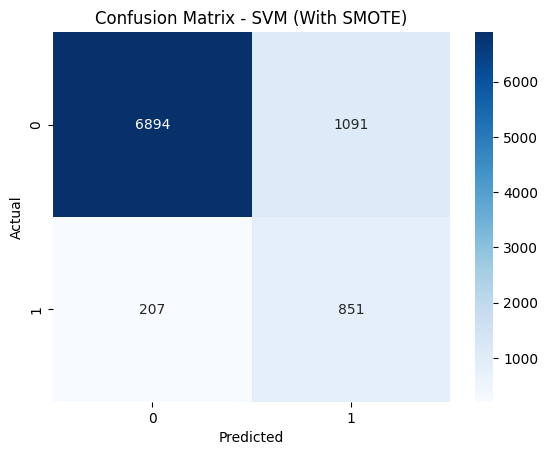

In [ ]:

# Bank Marketing Campaign Prediction

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve
)
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Classifiers
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

df = pd.read_csv(r"C:\Users\hrith\OneDrive\Desktop\ML Project\bank+marketing\bank\bank-full.csv", sep=';')
print("Data Shape:", df.shape)
print(df.head())

# Replace 'unknown' with NaN for imputation
df.replace('unknown', np.nan, inplace=True)

# Separate X, y
X = df.drop('y', axis=1)
y = df['y'].map({'yes': 1, 'no': 0})

# Identify categorical and numeric columns
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(exclude=['object']).columns

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=500, random_state=42),
    'Naive Bayes': GaussianNB(),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42)
}

param_grids = {
    'Decision Tree': {
        'clf__max_depth': [4, 6, 8, None],
        'clf__min_samples_leaf': [1, 2, 4],
        'clf__criterion': ['gini', 'entropy']
    },
    'Logistic Regression': {
        'clf__C': [0.1, 1, 10],
        'clf__penalty': ['l2'],
        'clf__solver': ['liblinear', 'saga']
    },
    'Naive Bayes': {},
    'SVM': {
        'clf__C': [0.1, 1, 10],
        'clf__gamma': ['scale', 'auto']
    }
}

results = []

for name, model in models.items():
    print(f"\nTraining {name} (without SMOTE)...")

    # Pipeline without SMOTE
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('clf', model)
    ])

    grid = GridSearchCV(
        pipeline, param_grids[name], cv=5, scoring='f1', n_jobs=-1
    )
    grid.fit(X_train, y_train)
    y_pred = grid.predict(X_test)
    y_proba = grid.predict_proba(X_test)[:, 1] if hasattr(grid.best_estimator_['clf'], "predict_proba") else None

    metrics_no_smote = {
        'Model': name + ' (No SMOTE)',
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba) if y_proba is not None else None
    }
    results.append(metrics_no_smote)

    print(f"Now training {name} (with SMOTE)...")

    # Pipeline with SMOTE
    imb_pipeline = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('clf', model)
    ])

    grid_smote = GridSearchCV(
        imb_pipeline, param_grids[name], cv=5, scoring='f1', n_jobs=-1
    )
    grid_smote.fit(X_train, y_train)
    y_pred_smote = grid_smote.predict(X_test)
    y_proba_smote = grid_smote.predict_proba(X_test)[:, 1] if hasattr(grid_smote.best_estimator_['clf'], "predict_proba") else None

    metrics_smote = {
        'Model': name + ' (With SMOTE)',
        'Accuracy': accuracy_score(y_test, y_pred_smote),
        'Precision': precision_score(y_test, y_pred_smote),
        'Recall': recall_score(y_test, y_pred_smote),
        'F1': f1_score(y_test, y_pred_smote),
        'ROC-AUC': roc_auc_score(y_test, y_proba_smote) if y_proba_smote is not None else None
    }
    results.append(metrics_smote)

results_df = pd.DataFrame(results)
print("\nFinal Results:")
display(results_df)

best_model_name = results_df.sort_values('F1', ascending=False).iloc[0]['Model']
print(f"\nBest Performing Model: {best_model_name}")

# Feature Importance
if 'Decision Tree' in best_model_name:
    best_pipe = grid_smote.best_estimator_
    ohe = best_pipe.named_steps['preprocessor'].named_transformers_['cat'].named_steps['encoder']
    encoded_features = ohe.get_feature_names_out(cat_cols)
    all_features = np.concatenate([num_cols, encoded_features])
    importances = best_pipe.named_steps['clf'].feature_importances_
    feat_imp = pd.DataFrame({'Feature': all_features, 'Importance': importances}).sort_values(by='Importance', ascending=False)
    plt.figure(figsize=(10,5))
    sns.barplot(x='Importance', y='Feature', data=feat_imp.head(15))
    plt.title('Top 15 Feature Importances - Decision Tree')
    plt.show()

cm = confusion_matrix(y_test, y_pred_smote)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
